Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

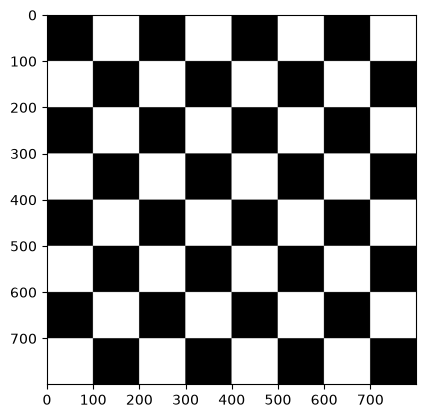

In [2]:
chess_img = np.zeros((800,800,1), dtype = np.uint8)

for x in range(0, 800, 100):
    for y in range(0, 800, 100):
        if (x/100)%2==0 and (y/100)%2!=0:
            chess_img[x:x+100, y:y+100] = 255
        elif (x/100)%2!=0 and (y/100)%2==0:
            chess_img[x:x+100, y:y+100] = 255

plt.imshow(chess_img, cmap='gray',vmin=0, vmax=255)
plt.show()

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

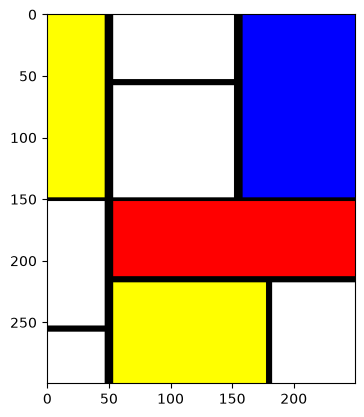

In [24]:
ancho = 250
alto = 300

mondrian_img = np.zeros((alto, ancho, 3), dtype=np.uint8)

mondrian_img[:,:,0] = 255
mondrian_img[:,:,1] = 255
mondrian_img[:,:,2] = 255

cv2.rectangle(mondrian_img, (0,0), (50,150), (255, 255, 0), -1)
cv2.rectangle(mondrian_img, (50,150), (ancho,215), (255, 0, 0), -1)
cv2.rectangle(mondrian_img, (155,0), (ancho,150), (0, 0, 255), -1)
cv2.rectangle(mondrian_img, (50,215), (180,alto), (255, 255, 0), -1)

cv2.line(mondrian_img, (50,0), (50,alto), (0, 0, 0), 5)
cv2.line(mondrian_img, (155,0), (155,148), (0, 0, 0), 5)
cv2.line(mondrian_img, (180,215), (180,alto), (0, 0, 0), 4)
cv2.line(mondrian_img, (0,150), (ancho,150), (0, 0, 0), 2)
cv2.line(mondrian_img, (50,215), (ancho,215), (0, 0, 0), 3)
cv2.line(mondrian_img, (50,55), (155,55), (0, 0, 0), 3)
cv2.line(mondrian_img, (0,255), (50,255), (0, 0, 0), 3)




plt.imshow(mondrian_img)
plt.show()

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [30]:
def max_and_min_px(h, w):
    global min_pos, max_pos

    min_pix = (int(frame[0, 0, 0]) + int(frame[0, 0, 1]) + int(frame[0, 0, 2]))
    max_pix = (int(frame[0, 0, 0]) + int(frame[0, 0, 1]) + int(frame[0, 0, 2]))

    for y in range(h):
        for x in range(w):
            pix = (int(frame[y, x, 0]) + int(frame[y, x, 1]) + int(frame[y, x, 2]))

            if pix > max_pix:
                max_pix = pix
                max_pos = (x, y)

            if pix < min_pix:
                min_pix = pix
                min_pos = (x, y)


In [31]:
vid = cv2.VideoCapture(0)
  
while True:      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        h, w, c = frame.shape

        max_and_min_px(h, w)

        cv2.circle(frame, max_pos, 5, (0,0,255), -1)
        cv2.circle(frame, min_pos, 5, (255,0,0), -1)
        
        # Muestra fotograma
        cv2.imshow('Cam', frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Usando funciones de OpenCV

In [ ]:
vid = cv2.VideoCapture(0)

while True:
    ret, frame = vid.read()

    if ret:

        scale_grey = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        min_pix, max_pix, min_pos, max_pos = cv2.minMaxLoc(scale_grey)

        cv2.circle(frame, max_pos, 5, (0, 0, 255), -1)
        cv2.circle(frame, min_pos, 5, (255, 0, 0), -1)

        cv2.imshow('Cam', frame)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [34]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)

#Imagen conjunta 2x original
popart = np.zeros((h*2,w*2,3), dtype = np.uint8)
tl = popart[0:h,0:w]
tr = popart[0:h,w:w+w]
bl = popart[h:h+h,0:w]
br = popart[h:h+h,w:w+w] 

while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        #Separamos canales
        b = frame[:,:,0]
        g = frame[:,:,1]
        r = frame[:,:,2]

        #Plano arriba izquierda
        tl[0:int(h/2),0:int(w/2),0] = b[0:int(h/2),0:int(w/2)]
        tl[0:int(h/2),0:int(w/2),2] = g[0:int(h/2),0:int(w/2)]
        tl[0:int(h/2),0:int(w/2),1] = r[0:int(h/2),0:int(w/2)]

        tl[0:int(h/2),int(w/2):w,0] = 255 - g[0:int(h/2),int(w/2):w]
        tl[0:int(h/2),int(w/2):w,2] = r[0:int(h/2),int(w/2):w]
        tl[0:int(h/2),int(w/2):w,1] = b[0:int(h/2),int(w/2):w]

        tl[int(h/2):h,0:int(w/2),0] = 255 - g[int(h/2):h,0:int(w/2)]
        tl[int(h/2):h,0:int(w/2),2] = r[int(h/2):h,0:int(w/2)]
        tl[int(h/2):h,0:int(w/2),1] = b[int(h/2):h,0:int(w/2)]

        tl[int(h/2):h,int(w/2):w,0] = b[int(h/2):h,int(w/2):w]
        tl[int(h/2):h,int(w/2):w,2] = g[int(h/2):h,int(w/2):w]
        tl[int(h/2):h,int(w/2):w,1] = r[int(h/2):h,int(w/2):w]

        #Plano arriba derecha
        tr[:,:,0] = 255 - r
        tr[:,:,1] = cv2.flip(g, 1)
        tr[:,:,2] = b
        
        #Plano arriba izquierda
        bl[:,:,0] = r
        bl[:,:,1] = 255 - b
        bl[:,:,2] = g

        for y in range(10, h, 20):
            for x in range(10, w, 20):
                cv2.circle(bl, (x, y), 2, (0, 255, 255), -1)

        
        #Plano arriba derecha
        br[:,:,0] = b
        br[:,:,1] = g
        br[:,:,2] = 255 - r
    
        # Muestra composición
        cv2.imshow('Cam', popart)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()